# Fig 6.16

Model of apoptosis signalling pathway

In [1]:
using Catalyst
using ModelingToolkit
using OrdinaryDiffEq
using Plots
Plots.default(linewidth=2)

In [2]:
rn = @reaction_network begin
    @parameters I(t)
    (k1, k2), 0 <--> C8
    k3 * (C3s + I), C8 --> C8s
    k4, C8s --> 0
    (k5, k6), C8s + BAR <--> C8sBAR
    (k7, k8), 0 <--> C3
    k9 * C8s, C3 --> C3s
    k10, C3s --> 0
    (k11, k12), C3s + IAP <--> C3sIAP
    (k13, k14), 0 <--> BAR
    (k15, k16 + k17 * C3s), 0 <--> IAP
    k18, C8sBAR --> 0
    k19, C3sIAP --> 0
end

Model ##ReactionSystem#265:
Unknowns (8): see unknowns(##ReactionSystem#265)
  C8(t)
  C8s(t)
  BAR(t)
  C8sBAR(t)
  ⋮
Parameters (20): see parameters(##ReactionSystem#265)
  I(t)
  k1
  k2
  k3
  ⋮

In [3]:
setdefaults!(rn, [
    :k1 => 507,
    :k2 => 3.9e-3,
    :k3 => 1e-5,
    :k4 => 5.8e-3,
    :k5 => 5e-4,
    :k6 => 0.21,
    :k7 => 81.9,
    :k8 => 3.9e-3,
    :k9 => 5.8e-6,
    :k10 => 5.8e-3,
    :k11 => 5e-4,
    :k12 => 0.21,
    :k13 => 40,
    :k14 => 1e-3,
    :k15 => 464,
    :k16 => 1.16e-2,
    :k17 => 3e-4,
    :k18 => 1.16e-2,
    :k19 => 1.73e-2,
    :I => 0.0,
    :C8 => 1.3E5,
    :C8s => 0.0,
    :C3 => 0.21E5,
    :C3s => 0.0,
    :BAR => 0.4E5,
    :IAP => 0.4E5,
    :C8sBAR => 0.0,
    :C3sIAP => 0.0
])

@unpack I = rn

osys = convert(ODESystem, rn; remove_conserved = true, discrete_events = [[100] => [I ~ 200], [1200] => [I ~ 0]]) |> structural_simplify
equations(osys)

┌ Warning: You are creating a system or problem while eliminating conserved quantities. Please note,
│         due to limitations / design choices in ModelingToolkit if you use the created system to
│         create a problem (e.g. an `ODEProblem`), or are directly creating a problem, you *should not*
│         modify that problem's initial conditions for species (e.g. using `remake`). Changing initial
│         conditions must be done by creating a new Problem from your reaction system or the
│         ModelingToolkit system you converted it into with the new initial condition map.
│         Modification of parameter values is still possible, *except* for the modification of any
│         conservation law constants (Γ), which is not possible. You might
│         get this warning when creating a problem directly.
│ 
│         You can remove this warning by setting `remove_conserved_warn = false`.
└ @ Catalyst ~/.julia/packages/Catalyst/48wH3/src/reactionsystem_conversions.jl:456


8-element Vector{Symbolics.Equation}:
 Differential(t)(C8(t)) ~ k1 - k2*C8(t) - k3*C8(t)*(C3s(t) + I(t))
 Differential(t)(C8s(t)) ~ -k4*C8s(t) + k6*C8sBAR(t) + k3*C8(t)*(C3s(t) + I(t)) - k5*BAR(t)*C8s(t)
 Differential(t)(BAR(t)) ~ k13 - k14*BAR(t) + k6*C8sBAR(t) - k5*BAR(t)*C8s(t)
 Differential(t)(C8sBAR(t)) ~ -k18*C8sBAR(t) - k6*C8sBAR(t) + k5*BAR(t)*C8s(t)
 Differential(t)(C3(t)) ~ k7 - k8*C3(t) - k9*C8s(t)*C3(t)
 Differential(t)(C3s(t)) ~ -k10*C3s(t) + k12*C3sIAP(t) - k11*C3s(t)*IAP(t) + k9*C8s(t)*C3(t)
 Differential(t)(IAP(t)) ~ k15 + k12*C3sIAP(t) - k11*C3s(t)*IAP(t) + (-k16 - k17*C3s(t))*IAP(t)
 Differential(t)(C3sIAP(t)) ~ -k12*C3sIAP(t) - k19*C3sIAP(t) + k11*C3s(t)*IAP(t)

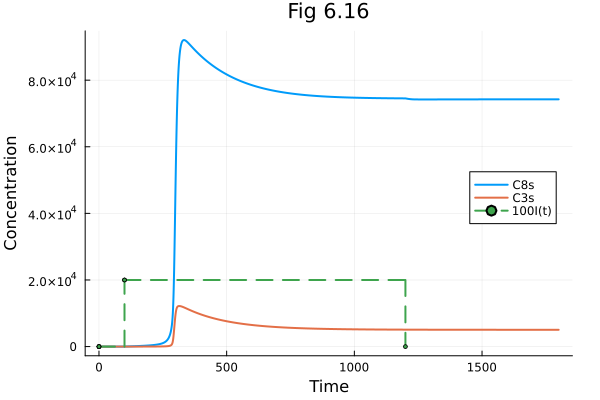

In [4]:
tspan = (0., 1800.)
prob = ODEProblem(osys, [], (0., 1800.), []);
sol = solve(prob)
plot(sol, idxs=[osys.C8s, osys.C3s, I*100], title="Fig 6.16", xlabel="Time", ylabel="Concentration", legend=:right, rightmargin=5*Plots.mm)

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*